# 02 — Walk-forward results: five models, five years

Each OOS year 2020–2024 uses an expanding window of all prior rows for training and the full year for test (see `src/mlr/validation.py`). Five models:

- `linear_ridge` — Ridge on standardised features, median-imputed
- `linear_lasso` — Lasso, same pipeline
- `lgbm_regressor` — LightGBM regressor, RMSE loss
- `xgb_regressor` — XGBoost regressor, RMSE loss
- `hist_mean` — per-symbol in-sample mean forward return

`hist_mean` is the zero-skill bar. Any learned model that doesn't beat it on both MAE and Pearson correlation has learned nothing useful about stock-level signal — it's just picking up market regime.

In [1]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.stats import spearmanr

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 110

ROOT = Path("..").resolve()
PREDS = ROOT / "reports" / "predictions" / "oos_2020_2024.parquet"
MACRO = sorted((ROOT / "data" / "raw").glob("macro_*.parquet"))[-1]

df = pd.read_parquet(PREDS)
df["date"] = pd.to_datetime(df["date"])
pred_cols = [c for c in df.columns if c.startswith("pred_")]
print(f"{len(df):,} OOS rows · {len(pred_cols)} models")
print("models:", [c.removeprefix('pred_') for c in pred_cols])

631,516 OOS rows · 5 models
models: ['linear_ridge', 'linear_lasso', 'lgbm_regressor', 'xgb_regressor', 'hist_mean']


## 1. Headline table: MAE, RMSE, direction accuracy, IC

In [2]:
def metric_block(y_true: pd.Series, y_pred: pd.Series) -> dict:
    m = y_true.notna() & y_pred.notna()
    yt = y_true[m].astype(float)
    yp = y_pred[m].astype(float)
    err = yp - yt
    mae  = err.abs().mean()
    rmse = np.sqrt((err ** 2).mean())
    dir_acc = ((np.sign(yp) == np.sign(yt)) & (yt != 0)).mean()
    pearson  = np.corrcoef(yt, yp)[0, 1]
    spearman = spearmanr(yt, yp).correlation
    return {"n": int(m.sum()), "MAE": mae, "RMSE": rmse,
            "dir_acc": dir_acc, "pearson": pearson, "spearman_IC": spearman}

rows = []
for c in pred_cols:
    rows.append({"model": c.removeprefix("pred_")} | metric_block(df["y_true"], df[c]))
overall = pd.DataFrame(rows).set_index("model")
overall.round(4)

,n,MAE,RMSE,dir_acc,pearson,spearman_IC
model,,,,,,
linear_ridge,622994,0.0786,0.1097,0.5145,0.0927,0.0705
linear_lasso,622994,0.0781,0.1091,0.5142,0.0961,0.0684
lgbm_regressor,622994,0.0888,0.1201,0.5075,0.1250,0.0706
xgb_regressor,622994,0.0922,0.1241,0.5009,0.1078,0.0663
hist_mean,622994,0.0740,0.1063,0.5619,0.0030,0.0179


MAE alone ranks `hist_mean` near the top — a per-symbol historical mean is a tough baseline on a fat-tailed, low-SNR target because it sidesteps the large-error quadrant entirely. The columns that actually measure signal are `pearson` and `spearman_IC`: those reward getting the cross-section ordering right, not just minimising squared error on a noisy target. Read those before drawing any conclusions.

## 2. By-year breakdown

In [3]:
df["year"] = df["date"].dt.year
blocks = []
for yr, g in df.groupby("year"):
    for c in pred_cols:
        row = {"year": yr, "model": c.removeprefix("pred_")}
        row |= metric_block(g["y_true"], g[c])
        blocks.append(row)
by_year = pd.DataFrame(blocks)

pivot_mae = by_year.pivot(index="year", columns="model", values="MAE").round(4)
pivot_ir  = by_year.pivot(index="year", columns="model", values="pearson").round(3)
print("MAE by year / model")
print(pivot_mae)
print("\nPearson by year / model")
print(pivot_ir)

MAE by year / model
model  hist_mean  lgbm_regressor  linear_lasso  linear_ridge  xgb_regressor
year                                                                       
2020      0.0977          0.0968        0.0964        0.0965         0.0982
2021      0.0630          0.1014        0.0619        0.0620         0.1056
2022      0.0820          0.0831        0.0822        0.0824         0.0835
2023      0.0654          0.0921        0.0815        0.0835         0.1018
2024      0.0621          0.0711        0.0688        0.0690         0.0725

Pearson by year / model
model  hist_mean  lgbm_regressor  linear_lasso  linear_ridge  xgb_regressor
year                                                                       
2020       0.072           0.303         0.320         0.321          0.294
2021      -0.040           0.100         0.065         0.062          0.110
2022      -0.032           0.216         0.139         0.143          0.188
2023       0.020          -0.001         0.

The headline row hides the most important thing. 2020 is the outlier year where every learned model delivers a clear Pearson advantage over HistMean — COVID was a macro-driven shock and the macro features caught it. 2021–2024 are much quieter. Pearson collapses for every model in 2023 and 2024, and the learned models stop separating from HistMean on MAE. This is the central empirical finding of the repo: absolute-return prediction is regime-dependent, and much of the apparent model skill in the headline table is just catching the 2020 macro shock.

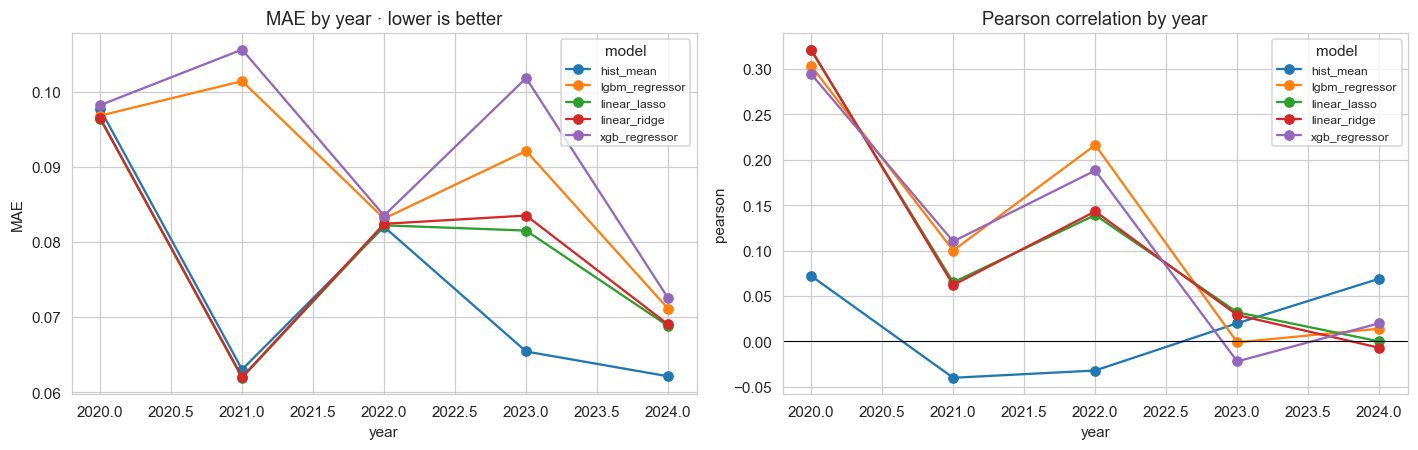

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True)
pivot_mae.plot(ax=axes[0], marker="o")
axes[0].set_title("MAE by year · lower is better")
axes[0].set_ylabel("MAE")
axes[0].legend(title="model", loc="best", fontsize=8)

pivot_ir.plot(ax=axes[1], marker="o")
axes[1].axhline(0, color="k", lw=0.7)
axes[1].set_title("Pearson correlation by year")
axes[1].set_ylabel("pearson")
axes[1].legend(title="model", loc="best", fontsize=8)
plt.tight_layout();

## 3. MAE vs. macro regime (VIX)

In [5]:
macro = pd.read_parquet(MACRO)
vix_daily = macro["vix"].rename("vix")

# daily mean absolute error per model
daily = df.groupby("date").apply(
    lambda g: pd.Series({
        c.removeprefix("pred_"): (g[c] - g["y_true"]).abs().mean()
        for c in pred_cols
    })
)
daily = daily.join(vix_daily, how="left")

# monthly aggregate so the scatter is readable
monthly = daily.resample("ME").mean()
monthly.tail()

,linear_ridge,linear_lasso,lgbm_regressor,xgb_regressor,hist_mean,vix
date,,,,,,
2024-08-31,0.063222,0.063180,0.060502,0.062239,0.053339,19.312273
2024-09-30,0.060819,0.060923,0.067385,0.066417,0.056118,17.769000
2024-10-31,0.079891,0.080009,0.080507,0.082544,0.076828,19.960870
2024-11-30,0.063200,0.063035,0.077498,0.073717,0.067077,16.121000
2024-12-31,0.057257,0.057147,0.054342,0.054384,0.062306,15.866190


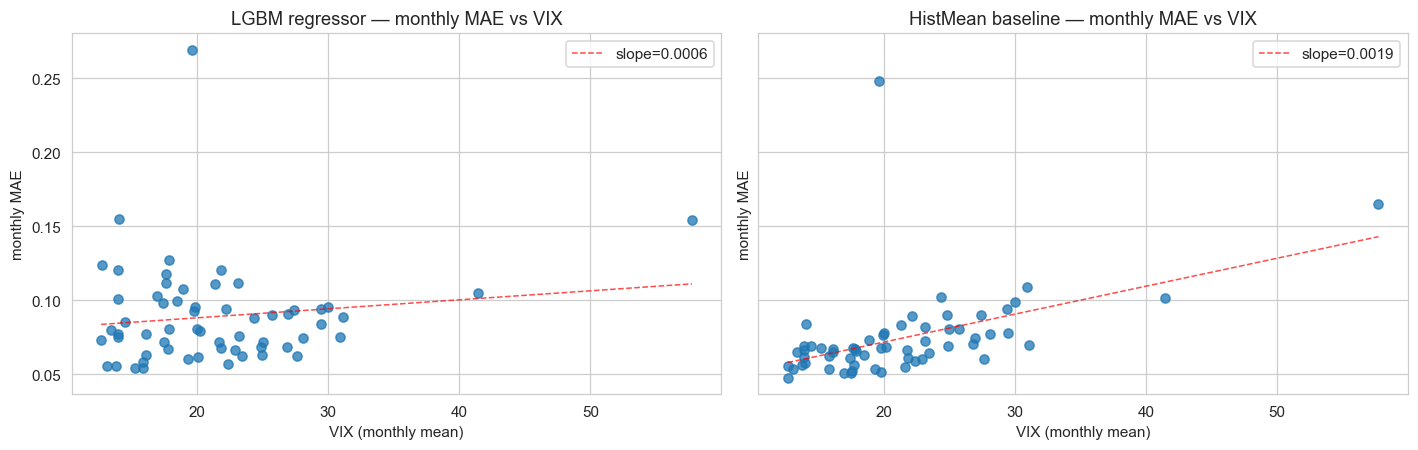

In [6]:
# Show the two most interesting contrasts: a learned model vs hist_mean
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2), sharex=True, sharey=True)
for ax, col, title in zip(axes, ["lgbm_regressor", "hist_mean"],
                          ["LGBM regressor", "HistMean baseline"]):
    ax.scatter(monthly["vix"], monthly[col], alpha=0.75)
    ax.set_title(f"{title} — monthly MAE vs VIX")
    ax.set_xlabel("VIX (monthly mean)")
    ax.set_ylabel("monthly MAE")
    # linear fit for eyeballing
    x, y = monthly["vix"].values, monthly[col].values
    m, b = np.polyfit(x, y, 1)
    xs = np.linspace(x.min(), x.max(), 100)
    ax.plot(xs, m * xs + b, "r--", lw=1, alpha=0.7,
            label=f"slope={m:.4f}")
    ax.legend()
plt.tight_layout();

Both families get systematically worse as VIX rises — noise is just larger during stress. What's interesting is that the *slope* is similar across models: the learned models don't beat the baseline harder during high-vol regimes. Whatever macro signal the tree models picked up in 2020 doesn't generalise cleanly to the next vol spike.

## Takeaways

The per-year breakdown is more informative than the headline table. HistMean is a stubbornly competitive MAE baseline — Pearson and IC are the fairer comparisons. LGBM and XGB only meaningfully separate from linear models in the 2020 COVID fold, where nonlinear macro-regime interactions were doing real work. Notebook 04 turns these predictions into a threshold strategy to test whether Pearson > 0 survives transaction costs.